<a href="https://colab.research.google.com/github/Arjun-kumar22/DEEP_Learning/blob/main/binary_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
accuracy_score , precision_score ,recall_score, f1_score,
confusion_matrix , classification_report
)

import data set customer churn

In [ ]:
df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
print("Number of sample",df.shape[0])
print("Number of features",df.shape[1])

Number of sample 7043
Number of features 21


In [ ]:
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


**FIX_TOTAL_CHARGES**

In [ ]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [ ]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [ ]:
df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)

In [ ]:
df["TotalCharges"].isnull().sum()

np.int64(0)

In [ ]:
df["TotalCharges"].isnull().sum()

np.int64(0)

In [ ]:
df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [ ]:
df["Churn"].value_counts()

,count
Churn,
0,5174
1,1869


In [ ]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [ ]:
X = pd.get_dummies(X, drop_first=True)

In [ ]:
X.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,customerID_0003-MKNFE,customerID_0004-TLHLJ,customerID_0011-IGKFF,customerID_0013-EXCHZ,customerID_0013-MHZWF,customerID_0013-SMEOE,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False


In [ ]:
X.shape

(7043, 7072)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5634, 7072)
Testing data: (1409, 7072)


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)


In [ ]:
logistic_model = LogisticRegression(max_iter=1000)

In [ ]:
logistic_model.fit(
    X_train_scaled,
    y_train
)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred_lr = logistic_model.predict(X_test_scaled)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42
)

In [ ]:
dt_model.fit(
    X_train,
    y_train
)

DecisionTreeClassifier(random_state=42)

In [ ]:
y_pred_dt = dt_model.predict(X_test)

Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [ ]:
rf_model.fit(
    X_train,
    y_train
)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred_rf = rf_model.predict(X_test)

**Evaluate the models**

In [ ]:
def evaluate_model(model_name, y_true, y_pred):

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print("Model:", model_name)
    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1-score :", f1)

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)

    print("Confusion Matrix:")
    print(cm)

    print("-" * 50)

In [ ]:
evaluate_model(
    "Logistic Regression",
    y_test,
    y_pred_lr
)

Model: Logistic Regression
Accuracy : 0.7842441447835344
Precision: 0.7215189873417721
Recall   : 0.3048128342245989
F1-score : 0.42857142857142855

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.96      0.87      1035
           1       0.72      0.30      0.43       374

    accuracy                           0.78      1409
   macro avg       0.76      0.63      0.65      1409
weighted avg       0.77      0.78      0.75      1409

Confusion Matrix:
[[991  44]
 [260 114]]
--------------------------------------------------


In [ ]:
evaluate_model(
    "Decision Tree",
    y_test,
    y_pred_dt
)

Model: Decision Tree
Accuracy : 0.7721788502484032
Precision: 0.5825545171339563
Recall   : 0.5
F1-score : 0.5381294964028777

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.87      0.85      1035
           1       0.58      0.50      0.54       374

    accuracy                           0.77      1409
   macro avg       0.71      0.69      0.69      1409
weighted avg       0.76      0.77      0.77      1409

Confusion Matrix:
[[901 134]
 [187 187]]
--------------------------------------------------


In [ ]:
evaluate_model(
    "Random Forest",
    y_test,
    y_pred_rf
)

Model: Random Forest
Accuracy : 0.7991483321504613
Precision: 0.6743295019157088
Recall   : 0.47058823529411764
F1-score : 0.5543307086614173

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.92      0.87      1035
           1       0.67      0.47      0.55       374

    accuracy                           0.80      1409
   macro avg       0.75      0.69      0.71      1409
weighted avg       0.79      0.80      0.79      1409

Confusion Matrix:
[[950  85]
 [198 176]]
--------------------------------------------------


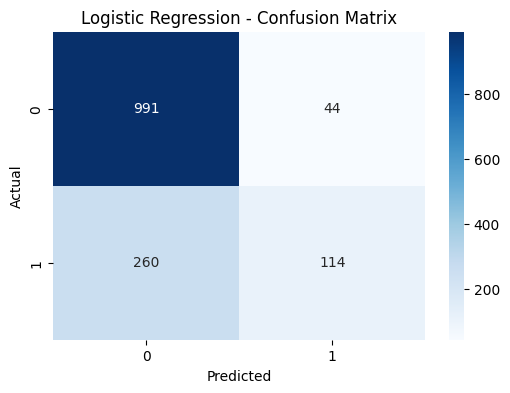

In [ ]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Confusion Matrix")

plt.show()

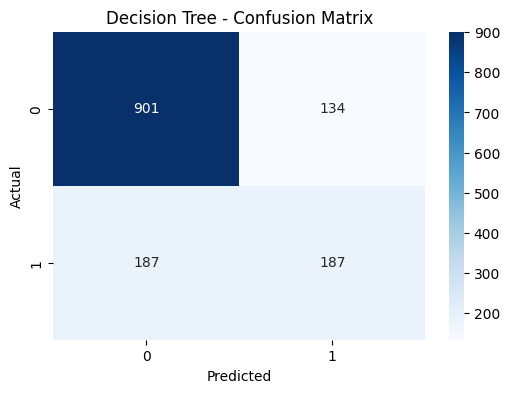

In [ ]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree - Confusion Matrix")

plt.show()

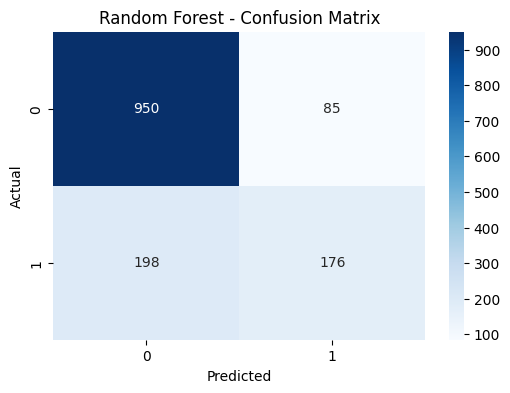

In [ ]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest - Confusion Matrix")

plt.show()

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ],

    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf)
    ],

    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf)
    ],

    "F1-Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.784244,0.721519,0.304813,0.428571
1,Decision Tree,0.772179,0.582555,0.500000,0.538129
2,Random Forest,0.799148,0.674330,0.470588,0.554331


In [ ]:
best_model = results.loc[
    results["F1-Score"].idxmax()
]

print("Best Performing Model:")
print(best_model)

Best Performing Model:
Model        Random Forest
Accuracy          0.799148
Precision          0.67433
Recall            0.470588
F1-Score          0.554331
Name: 2, dtype: object


**Conclusion

The Random Forest model achieved 79.91% accuracy with a precision of 67.43%, recall of 47.06%, and F1-score of 55.43%. Although the model provided reasonable accuracy, its relatively low recall indicates that it missed a significant number of positive cases. Therefore, Random Forest was the best-performing model among the evaluated models based on the overall comparison, but there is still room for improvement.**